# Chapter 6 - Data Manipulation

*This notebook contains all the sample code in Chapter 6.*


## Outline

- [Pandas](#pandas)
    - [Data types and basic operations](#pandas_types)
    - [Basic data manipulations](#data_manipulation)
- [GeoPandas](#geopandas)
- [Ibis](#ibis)
- [SQLite3](#sqlite)
- [Data and datasets](#datasets)
    - [Data representation](#data_representation)
    - [Useful file formats](#file_formats)

<a id="pandas"></a>
## Pandas


**Pandas** is imported as:

In [1]:
import pandas as pd

<a id="pandas_types"></a>
### Data types and basic operations


#### Pandas Series

A Pandas Series is a one-dimensional array of indexed data. It can be created from a list or array as follows:

In [2]:
data = pd.Series([0.25, 0.5, 0.75, 1.0])
data

0    0.25
1    0.50
2    0.75
3    1.00
dtype: float64

The values are simply a familiar **NumPy** array:

In [3]:
data.values

array([0.25, 0.5 , 0.75, 1.  ])

The index is an array-like object of type `pd.Index`:

In [4]:
data.index

RangeIndex(start=0, stop=4, step=1)

Like with a **NumPy** array, data can be accessed using standard *indexing* and *slicing*:


In [5]:
data[1]

0.5

In [6]:
data[1:3]

1    0.50
2    0.75
dtype: float64

Note that the **slice** operation slices also the index.

A general way to construct a **Series** is:

In [7]:
index = range(4)
s = pd.Series(data, index=index)
s

0    0.25
1    0.50
2    0.75
3    1.00
dtype: float64

where the *index* defines the labels of the data:

In [8]:
import numpy as np

s = pd.Series(np.random.randn(5), index=['a', 'b', 'c', 'd', 'e'])
s

a    1.092468
b   -2.007175
c   -1.276896
d    0.823854
e   -1.206753
dtype: float64

Series elements can be accessed via their **labels**:

In [9]:
s['b']

-2.0071745992596233

Series can be created from a **dictionary**:

In [10]:
d = {'b': 1, 'a': 0, 'c': 2}

pd.Series(d)

b    1
a    0
c    2
dtype: int64

Missing entries are filled with `NaN`:

In [11]:
pd.Series(d, index=['b', 'c', 'd', 'a'])

b    1.0
c    2.0
d    NaN
a    0.0
dtype: float64

Pandas supports two main indexing approaches (**indexers**): 

1. `loc`, which uses the explicit indexing (*label-based*):

In [12]:
s.loc['b']

-2.0071745992596233

2. `iloc`, which uses the implicit indexing (*position-based*):

In [13]:
s.iloc[1]

-2.0071745992596233

#### Pandas DataFrame

DataFrame is a 2-dimensional labeled data structure with columns that may have different types. A DataFrame can be constructed from Series, by constructing a dictionary of Series: 

In [14]:
d1 = pd.Series([1., 2., 3.], index=['a', 'b', 'c'])
d2 = pd.Series([1., 2., 3., 4.], index=['a', 'b', 'c', 'd'])
d3 = pd.Series([1., 2., 4.], index=['a', 'b', 'd'])

d = {'one': d1, 'two': d2, 'three': d3}
df = pd.DataFrame(d)
df

,one,two,three
a,1.0,1.0,1.0
b,2.0,2.0,2.0
c,3.0,3.0,NaN
d,NaN,4.0,4.0


A DataFrame can be also constructed from a two-dimensional NumPy array:

In [15]:
data = np.random.rand(3, 2)
df2 = pd.DataFrame(data, columns=['One', 'Two'], index=['a', 'b', 'c'])
df2

,One,Two
a,0.478127,0.374480
b,0.402454,0.706846
c,0.310015,0.028343


The index, column names, and data can be accessed as follows:

In [16]:
df2.index

Index(['a', 'b', 'c'], dtype='object')

In [17]:
df2.columns

Index(['One', 'Two'], dtype='object')

In [18]:
df2.values

array([[0.47812726, 0.37447993],
       [0.40245441, 0.70684555],
       [0.31001543, 0.0283433 ]])

**Columns** can be accessed by name:

In [19]:
df['two']

a    1.0
b    2.0
c    3.0
d    4.0
Name: two, dtype: float64

This is equivalent also to:

In [20]:
df.two

a    1.0
b    2.0
c    3.0
d    4.0
Name: two, dtype: float64

Rows can be accessed via **slicing** (of *indices* or *labels*):

In [21]:
df[1:3]  # or df['b':'c']

,one,two,three
b,2.0,2.0,2.0
c,3.0,3.0,NaN


**Attention!** While **indexing** refers to columns, **slicing** refers to rows.

This is more evident if both indexes and columns names are **numbers**:

In [22]:
data = np.random.rand(3, 2)
df3 = pd.DataFrame(data)
df3

,0,1
0,0.029715,0.339783
1,0.493393,0.181450
2,0.641130,0.093342


In [23]:
df3[1]

0    0.339783
1    0.181450
2    0.093342
Name: 1, dtype: float64

In [24]:
df3[1:2]

,0,1
1,0.493393,0.18145


Also for a DataFrame we can use an **explicit** or by an **implicit** indexing:
1. `loc`, which uses the explicit indexing (*label-based*):

In [25]:
df.loc[['a', 'b']]

,one,two,three
a,1.0,1.0,1.0
b,2.0,2.0,2.0


2. `iloc`, which uses the implicit indexing (*position-based*):

In [26]:
df.iloc[[1, 2]]

,one,two,three
b,2.0,2.0,2.0
c,3.0,3.0,NaN


3. `iat`, which accesses a single value for a row/column pair by integer position (*fast scalar access*):

In [27]:
df.iat[1, 2]

2.0

Finally, `loc` and `iloc` can be used also to extract some sub-sets of data:

In [28]:
df.loc[:'b',:'two']

,one,two
a,1.0,1.0
b,2.0,2.0


In [29]:
df.iloc[:3,:2]

,one,two
a,1.0,1.0
b,2.0,2.0
c,3.0,3.0


Values can also be modified using these indexers:

In [30]:
df.iloc[0, 1] = 5
df

,one,two,three
a,1.0,5.0,1.0
b,2.0,2.0,2.0
c,3.0,3.0,NaN
d,NaN,4.0,4.0


To inspect data from Series or DataFrame objects:

In [31]:
long_series = pd.Series(np.random.randn(1000))

long_series.head()

0    0.341707
1   -0.349072
2    0.326628
3    0.827141
4    0.687611
dtype: float64

In [32]:
long_series.tail(3)

997   -2.227972
998    0.996091
999   -1.458034
dtype: float64

Given the following DataFrame object:

In [33]:
index = pd.date_range('1/1/2000', periods=8)
df = pd.DataFrame(np.random.randn(8, 3), index=index, columns=['A', 'B', 'C'])
df

,A,B,C
2000-01-01,1.404233,-1.441621,0.256447
2000-01-02,-0.731343,-0.908442,-0.161112
2000-01-03,-1.394643,0.580798,1.905174
2000-01-04,1.740693,-0.584095,0.159013
2000-01-05,0.358021,-0.304894,0.462384
2000-01-06,0.791985,0.103819,-0.058540
2000-01-07,0.389439,-0.541693,-1.049571
2000-01-08,0.954323,-0.694775,-0.263324


*metadata* can be accessed and modified easily:

In [34]:
df[:2]

,A,B,C
2000-01-01,1.404233,-1.441621,0.256447
2000-01-02,-0.731343,-0.908442,-0.161112


In [35]:
df.columns = [x.lower() for x in df.columns]
df[:5]

,a,b,c
2000-01-01,1.404233,-1.441621,0.256447
2000-01-02,-0.731343,-0.908442,-0.161112
2000-01-03,-1.394643,0.580798,1.905174
2000-01-04,1.740693,-0.584095,0.159013
2000-01-05,0.358021,-0.304894,0.462384


To convert a Series to a **NumPy** array:

In [36]:
s = pd.Series(np.random.randn(5), index=['a', 'b', 'c', 'd', 'e'])

s.to_numpy()

array([-0.52879166,  1.59956238,  1.29866004, -0.74877568, -0.30714519])

In [37]:
np.asarray(s)

array([-0.52879166,  1.59956238,  1.29866004, -0.74877568, -0.30714519])

Pandas supports **element-wise** operations with automatic *alignment*:

In [38]:
df = pd.DataFrame({
    'one': pd.Series(np.random.randn(3), index=['a', 'b', 'c']),
    'two': pd.Series(np.random.randn(4), index=['a', 'b', 'c', 'd']),
    'three': pd.Series(np.random.randn(3), index=['b', 'c', 'd'])})
				
row = df.iloc[1]
column = df['two']

df.sub(row, axis='columns')

,one,two,three
a,-1.860624,1.335775,NaN
b,0.000000,0.000000,0.000000
c,0.667494,1.882114,1.553552
d,NaN,0.652790,2.237213


In [39]:
df.sub(column, axis='index')

,one,two,three
a,-1.931861,0.0,NaN
b,1.264539,0.0,-1.533667
c,0.049919,0.0,-1.862229
d,NaN,0.0,0.050757


Iteration behavior depends on the object type. For example:

In [40]:
df = pd.DataFrame({'col1': np.random.randn(3), 'col2': np.random.randn(3)}, index=['a', 'b', 'c'])
for col in df:
    print(col)

col1
col2


<a id="data_manipulation"></a>
### Basic data manipulations


#### Reading and writing data

To **load** the titanic passenger data, available as a CSV file:

In [41]:
titanic = pd.read_csv("../data/titanic.csv")

The equivalent read function for Excel data:


In [42]:
titanic = pd.read_excel('../data/titanic.xlsx', sheet_name='passengers')

The `header=None` option prevents Pandas from interpreting the first row as column names.

To **write** data to CSV file:

In [43]:
titanic.to_csv('../data/titanic_new.csv', index=False)

Similarly, to **write** data to Excel file:

In [44]:
titanic.to_excel('../data/titanic_new.xlsx', sheet_name='passengers', index=False)

The option `index=False` ensures that *row indices* are **not** written to the output file.

#### Select a subset of a DataFrame

To **select** a single column, use square brackets `[ ]` with the column name or the list of column names:

In [45]:
titanic = pd.read_csv("../data/titanic.csv")

ages = titanic["Age"]
ages

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [46]:
age_sex = titanic[["Age", "Sex"]]
age_sex

,Age,Sex
0,22.0,male
1,38.0,female
2,26.0,female
3,35.0,female
4,35.0,male
...,...,...
886,27.0,male
887,19.0,female
888,NaN,female
889,26.0,male


To **select** rows based on a conditional expression:

In [47]:
above_35 = titanic[titanic["Age"] > 35]
class_23 = titanic[(titanic["Pclass"] == 2) | (titanic["Pclass"] == 3)]

Logical operators can be used:

In [48]:
adult_names = titanic.loc[titanic["Age"] > 35, "Name"]
some_passengers = titanic.iloc[9:25, 2:5]
titanic.iloc[0:3, 3] = "anonymous"

#### Deleting some rows or columns

To **delete** a row or a column (or both) from a DataFrame:

In [49]:
# Removing two specified columns
new_df1 = titanic.drop(['Age', 'Sex'], axis=1) 

# Removing two specified rows
new_df2 = titanic.drop([0, 1], axis=0)

# Removing both a row and a column
new_df3 = titanic.drop(index=20, columns='Sex')

#### Creating new columns derived from existing columns

To **create** new column by performing mathematical operation between other columns or by renaming the columns:

In [50]:
table = pd.read_csv("../data/mydata.csv")
table["col4"] = table["col1"] * 1.882
table["col5"] = table["col2"] / table["col3"]

table_new = table.rename(
  columns={"col1": "BETR801",
           "col2": "FR04014",
           "col3": "Roma"})

table_new

,BETR801,FR04014,Roma,col4,col5
0,0.844548,1.468936,0.882553,1.589439,1.664417
1,-0.226764,-1.546553,0.501065,-0.426770,-3.086532
2,1.172823,0.445329,-0.304587,2.207253,-1.462075
3,0.663638,-1.228805,0.543703,1.248967,-2.260067
4,-0.060712,-1.917687,-1.148560,-0.114260,1.669645
5,0.803664,-1.823464,-0.563253,1.512496,3.237380
6,1.318961,0.516707,-0.970342,2.482285,-0.532500
7,0.322948,-1.227461,0.343019,0.607788,-3.578405


#### Evaluating summary statistics

One powerful characteristics is the ability of **evaluating** aggregating statistics:

In [51]:
titanic = pd.read_csv("../data/titanic.csv")

titanic["Age"].mean()

29.69911764705882

In [52]:
titanic[["Age", "Fare"]].median()

Age     28.0000
Fare    14.4542
dtype: float64

In [53]:
titanic.agg({'Age': ['min', 'max', 'median', 'skew'],
            'Fare': ['min', 'max', 'median', 'mean']})

,Age,Fare
min,0.420000,0.000000
max,80.000000,512.329200
median,28.000000,14.454200
skew,0.389108,NaN
mean,NaN,32.204208


In [54]:
titanic[["Sex", "Age"]].groupby("Sex").mean()

,Age
Sex,
female,27.915709
male,30.726645


In [55]:
titanic["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

The `groupby` operation allows to make **aggregation** conditionally on some label or index.

The aggregating statistic can be calculated for multiple columns:

In [56]:
titanic[["Age", "Fare"]].describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


#### Sorting and reshaping

To **sort** values in a DataFrame:

In [57]:
titanic.sort_values(by="Age")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,NaN,C
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [58]:
titanic.sort_values(by=['Pclass', 'Age'], ascending=False)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
280,281,0,3,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,NaN,Q
483,484,1,3,"Turkula, Mrs. (Hedwig)",female,63.0,0,0,4134,9.5875,NaN,S
326,327,0,3,"Nysveen, Mr. Johan Hansen",male,61.0,0,0,345364,6.2375,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
766,767,0,1,"Brewe, Dr. Arthur Jackson",male,NaN,0,0,112379,39.6000,NaN,C
793,794,0,1,"Hoyt, Mr. William Fisher",male,NaN,0,0,PC 17600,30.6958,NaN,C
815,816,0,1,"Fry, Mr. Richard",male,NaN,0,0,112058,0.0000,B102,S
839,840,1,1,"Marechal, Mr. Pierre",male,NaN,0,0,11774,29.7000,C47,C


In [59]:
table_subset = titanic.sort_index().groupby(["Pclass"])
table_subset.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S


#### Combining data from multiple tables

To **combine** two tables with a similar structure in a single table along *rows*:

In [60]:
no2_data = pd.read_csv("../data/air_quality_no2_long.csv")
pm25_data = pd.read_csv("../data/air_quality_pm25_long.csv")

air_quality = pd.concat([pm25_data, no2_data], axis=0)
air_quality

,city,country,date.utc,location,parameter,value,unit
0,Antwerpen,BE,2019-06-18 06:00:00+00:00,BETR801,pm25,18.0,µg/m³
1,Antwerpen,BE,2019-06-17 08:00:00+00:00,BETR801,pm25,6.5,µg/m³
2,Antwerpen,BE,2019-06-17 07:00:00+00:00,BETR801,pm25,18.5,µg/m³
3,Antwerpen,BE,2019-06-17 06:00:00+00:00,BETR801,pm25,16.0,µg/m³
4,Antwerpen,BE,2019-06-17 05:00:00+00:00,BETR801,pm25,7.5,µg/m³
...,...,...,...,...,...,...,...
2063,London,GB,2019-05-07 06:00:00+00:00,London Westminster,no2,26.0,µg/m³
2064,London,GB,2019-05-07 04:00:00+00:00,London Westminster,no2,16.0,µg/m³
2065,London,GB,2019-05-07 03:00:00+00:00,London Westminster,no2,19.0,µg/m³
2066,London,GB,2019-05-07 02:00:00+00:00,London Westminster,no2,19.0,µg/m³


or along *columns*:

In [61]:
air_quality = pd.concat([pm25_data, no2_data], axis=1)
air_quality.head()

,city,country,date.utc,location,parameter,value,unit,city,country,date.utc,location,parameter,value,unit
0,Antwerpen,BE,2019-06-18 06:00:00+00:00,BETR801,pm25,18.0,µg/m³,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³
1,Antwerpen,BE,2019-06-17 08:00:00+00:00,BETR801,pm25,6.5,µg/m³,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³
2,Antwerpen,BE,2019-06-17 07:00:00+00:00,BETR801,pm25,18.5,µg/m³,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³
3,Antwerpen,BE,2019-06-17 06:00:00+00:00,BETR801,pm25,16.0,µg/m³,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³
4,Antwerpen,BE,2019-06-17 05:00:00+00:00,BETR801,pm25,7.5,µg/m³,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³


#### Plotting

Pandas includes built-in **plotting** functionality:

<Axes: >

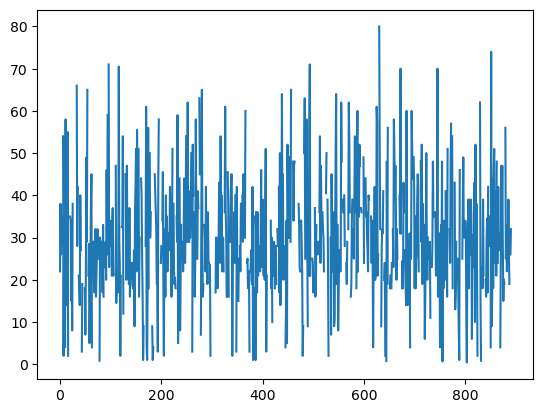

In [62]:
titanic['Age'].plot()

<Axes: >

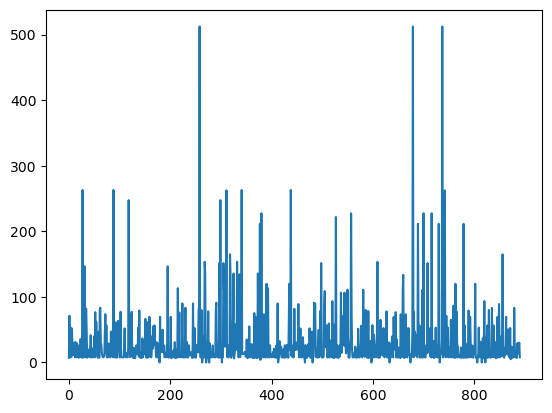

In [63]:
titanic['Fare'].plot(kind='line')

<Axes: >

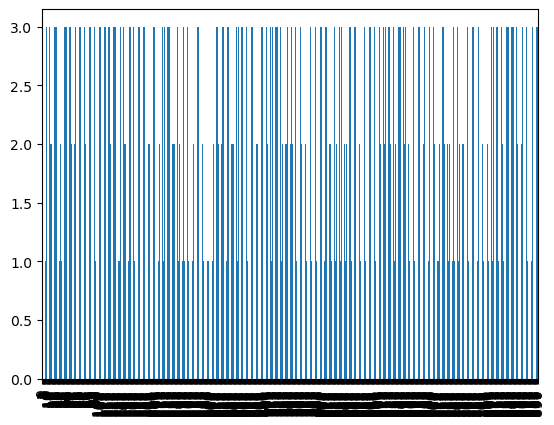

In [64]:
titanic['Pclass'].plot(kind='bar')

<Axes: ylabel='Frequency'>

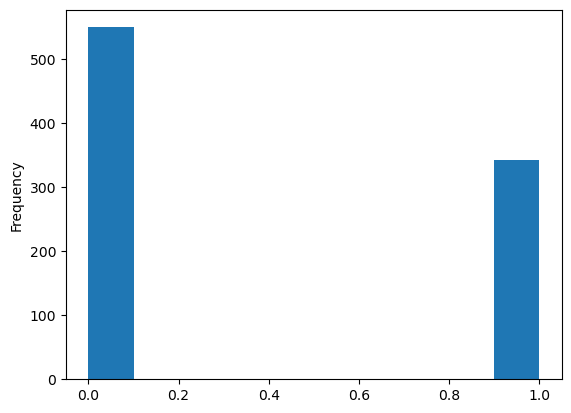

In [65]:
titanic['Survived'].plot(kind='hist')

<Axes: xlabel='Pclass', ylabel='Fare'>

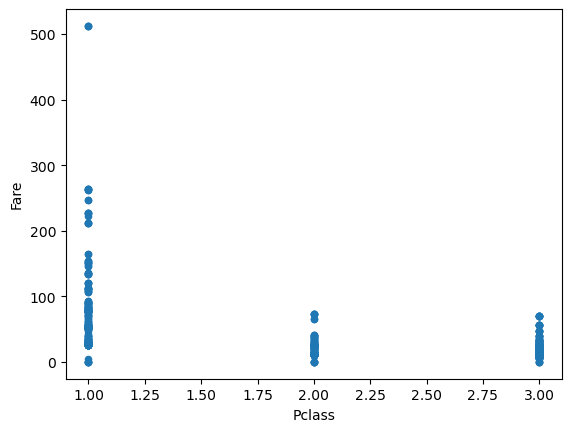

In [66]:
titanic.plot(x='Pclass',y='Fare',kind='scatter')

#### Manipulating textual data

WPandas provide some useful functions to manipulate text.

For example, to make all characters **lowercase**:

In [67]:
titanic = pd.read_csv("../data/titanic.csv")
titanic["Name"].str.lower()

0                                braund, mr. owen harris
1      cumings, mrs. john bradley (florence briggs th...
2                                 heikkinen, miss. laina
3           futrelle, mrs. jacques heath (lily may peel)
4                               allen, mr. william henry
                             ...                        
886                                montvila, rev. juozas
887                         graham, miss. margaret edith
888             johnston, miss. catherine helen "carrie"
889                                behr, mr. karl howell
890                                  dooley, mr. patrick
Name: Name, Length: 891, dtype: object

or to **extract** the part before the comma and **create** a **new** column:

In [68]:
titanic["Surname"] = titanic["Name"].str.split(",").str.get(0)
titanic["Surname"]

0         Braund
1        Cumings
2      Heikkinen
3       Futrelle
4          Allen
         ...    
886     Montvila
887       Graham
888     Johnston
889         Behr
890       Dooley
Name: Surname, Length: 891, dtype: object

To **extract** data that **contains** a specific word:

In [69]:
idx = titanic["Name"].str.contains("Countess")
passengers = titanic[idx]
passengers

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname
759,760,1,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.5,B77,S,Rothes


It is possible to **replace** some words with others:

In [70]:
titanic["Sex_short"] = titanic["Sex"].replace({"male": "M", "female": "F"})
titanic["Sex_short"]

0      M
1      F
2      F
3      F
4      M
      ..
886    M
887    F
888    F
889    M
890    M
Name: Sex_short, Length: 891, dtype: object

#### Handling missing data

Missing data can be represented by `None`:

In [71]:
import numpy as np

v1 = np.array([1, None, 3, 4])
print(v1)

[1 None 3 4]


or by `NaN` (acronym for *Not a Number*):

In [72]:
v2 = np.array([1, np.nan, 3, 4])
print(v2)

[ 1. nan  3.  4.]


Missing data in **Pandas** is typically represented by `NaN` and `None`:

In [73]:
v3 = pd.Series([1, np.nan, 2, None])
v3

0    1.0
1    NaN
2    2.0
3    NaN
dtype: float64

There are several useful methods for detecting, removing, and replacing null values in Pandas data structures:
* `isnull()`: generate a Boolean mask indicating missing values
* `notnull()`: opposite of `isnull()`
* `dropna()`: return a filtered version of the data
* `fillna()`: return a copy of the data with missing values**filled** or **imputed**

For example:

In [74]:
data = pd.Series([1, np.nan, 2, None, 3], index=list('abcde'))

data_new = data.fillna(0)
data_new

a    1.0
b    0.0
c    2.0
d    0.0
e    3.0
dtype: float64

For **counting** the number of missing values in a DataFrame:

In [75]:
N = titanic.isnull().sum().sum()
print(N)

866


Hence, we can remove rows or the columns containing missing values:

In [76]:
titanic1 = titanic.dropna()
titanic1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Sex_short
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,F
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,F
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,McCarthy,M
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,Sandstrom,F
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,Bonnell,F


In [77]:
titanic2 = titanic.dropna(axis='columns')
titanic2.head()

,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Surname,Sex_short
0,1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,7.2500,Braund,M
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,71.2833,Cumings,F
2,3,1,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,7.9250,Heikkinen,F
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,53.1000,Futrelle,F
4,5,0,3,"Allen, Mr. William Henry",male,0,0,373450,8.0500,Allen,M


<a id="geopandas"></a>
## GeoPandas

**GeoPandas** is an extension of Pandas designed for working with *geospatial* data.

A **GeoDataFrame** can be created from existing data as:

In [78]:
import geopandas as gpd
from shapely.geometry import Point

data = {'city': ['Rome', 'Paris', 'Berlin'], 'lon': [12.5, 2.35, 13.4], 'lat': [41.9, 48.85, 52.52]}

df = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data['lon'], data['lat']), crs="EPSG:4326")

**GeoPandas** supports common geospatial file formats such as Shapefile and GeoJSON:

In [79]:
gdf = gpd.read_file("../data/maps/countries.shp")
# gdf.to_file("output.geojson", driver="GeoJSON")

GeoPandas enables **spatial operations** directly on geometries:

In [80]:
italy = gdf[gdf['COUNTRY'] == 'Italy']

gdf['area'] = gdf.geometry.area
gdf['centroid'] = gdf.geometry.centroid

It is possible also to make **coordinate transformations**:

In [81]:
gdf = gdf.to_crs(epsg=3857)

GeoPandas supports **spatial joins**:

In [82]:
regions = gpd.read_file("../data/maps/regions.shp")
cities = gpd.read_file("../data/maps/cities.shp")

joined = gpd.sjoin(regions, cities, predicate="covers")

*Overlay* operations allow **combining** geometries:

In [83]:
# intersection = gpd.overlay(gdf1, gdf2, how="intersection")
# difference = gpd.overlay(gdf1, gdf2, how="difference")

GeoPandas integrates with **Matplotlib** for quick plotting:

<Axes: >

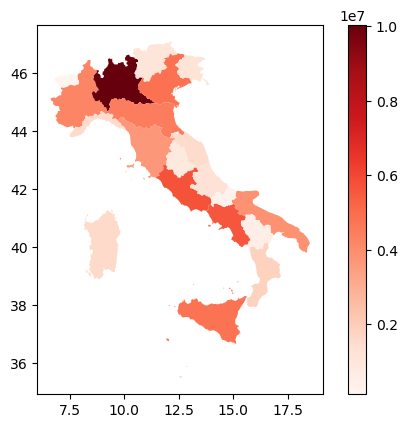

In [84]:
# Add population information to regions
population = [122532,4251868,1510143,10033918,1086252,4853472,1193284,3657716,851473,5709178,1269118,3877395,5582337,287814,530004,1834646,4787390,1562381,4461998,1480545]
regions['population'] = population

regions.plot(column='population', cmap='Reds', legend=True)

Multiple **layers** can be also combined:

<Axes: >

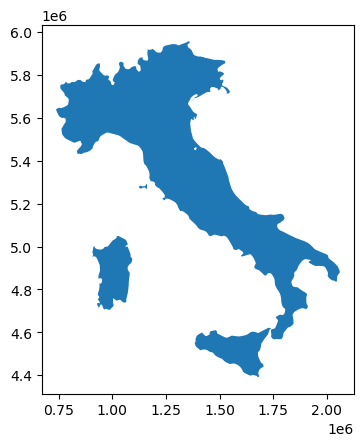

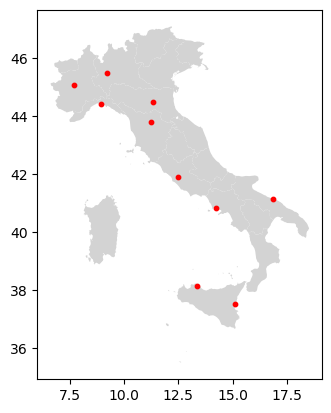

In [85]:
ax1 = italy.plot()
ax2 = regions.plot(color='lightgray')
cities.plot(ax=ax2, color='red', markersize=10)

As a further example, we can compute **distances** between cities:

In [86]:
rome = df.loc[df['city'] == 'Rome'].geometry.iloc[0]
df['distance_to_rome'] = df.distance(rome)

C:\Users\miche\AppData\Local\Temp\ipykernel_22732\3653554410.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df['distance_to_rome'] = df.distance(rome)


If we need a data **projection**:

In [87]:
df_proj = df.to_crs(epsg=3857)
rome = df_proj.loc[df_proj['city'] == 'Rome'].geometry.iloc[0]
df_proj['distance_to_rome'] = df_proj.distance(rome)

<a id="ibis"></a>
## Ibis

The **Ibis** library is a high-level Python framework designed for analytical data processing, especially when working with large datasets stored in *databases* or *distributed systems*.

A typical **Ibis** workflow consists of three steps:
1. **connecting** to a backend;
2. **defining** expressions (*queries*);
3. **executing* the query.

For example:

In [88]:
import ibis

# Connect to a database
con = ibis.duckdb.connect()

# Load a CSV file as a table
t = con.read_csv("../data/sqdata.csv")

# Select rows where age > 30 and keep specific columns
filtered = t[t.age > 30][["name", "age"]]

# Group by a column and compute aggregate statistics
result = t.group_by("city").aggregate(avg_age=t.age.mean(), count=t.count())

# Trigger execution and return a pandas DataFrame
df = result.execute()

df.head()

C:\Users\miche\AppData\Local\Temp\ipykernel_22732\1581696472.py:10: FutureWarning: Selecting/filtering arbitrary expressions in `Table.__getitem__` is deprecated and will be removed in version 10.0. Please use `Table.select` or `Table.filter` instead.
  filtered = t[t.age > 30][["name", "age"]]


,city,avg_age,count
0,Rome,36.0,3
1,Berlin,35.0,2
2,Paris,48.5,2


To perform an **end-to-end** *analytical query*:

In [89]:
query = (t.filter(t.price > 100).group_by(t.category).aggregate(total_sales=t.price.sum()))

df = query.execute()

df.head()

,category,total_sales
0,A,560.5
1,B,450.0


<a id="sqlite"></a>
## SQLite3

**SQLite3** is a self-contained, serverless, and zero-configuration database engine that stores entire databases in a single file. Specifically, it is a lightweight relational database management system (**DBMS**) that stores data and executes *SQL queries*. It is highly popular for local applications, mobile apps, and backend development.

The following example create a database file, create a table containing identifier, name and salary of employees, and insert a new record inside the table. Then a query is performed and the database is finally closed:

In [90]:
import sqlite3

# 1. Connect to the database (creates the file if it doesn't exist)
conn = sqlite3.connect('../data/mydb.db')
cur  = conn.cursor()

# 2. Create a table
cur.execute('''
    CREATE TABLE IF NOT EXISTS employees (
        id INTEGER PRIMARY KEY,
        name TEXT,
        salary REAL
    )
''')

# 3. Insert a record
cur.execute("INSERT INTO employees (name, salary) VALUES (?, ?)", ('Bob', 55000.0))
conn.commit() # Save changes

# 4. Query data
cur.execute("SELECT * FROM employees")
rows = cur.fetchall()
for row in rows:
    print(row)

# 5. Close the connection
conn.close()

(1, 'Bob', 55000.0)


<a id="datasets"></a>
## Data and datasets


Numerous online platforms provide access to datasets covering a wide range of application domains. Mainly are:
1. [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php)
2. [Kaggle](https://www.kaggle.com/datasets)
3. [OpenML](https://www.openml.org/)
4. [Google's Datasets Search Engine](https://toolbox.google.com/datasetsearch)
5. [Awesome Public Datasets](https://github.com/awesomedata/awesome-public-datasets)
6. [Microsoft Datasets](https://msropendata.com/)
7. [Amazon Datasets](https://registry.opendata.aws/)
8. [VisualData](https://www.visualdata.io/)

<a id="data_representation"></a>
### Data representation


A **dataset** consists of a collection of instances (or *samples*), each described by a set of **features** that characterize the observation.

A common representation is the tabular format, where the data can be conceptually divided into two components. The first component is the **feature matrix**, typically denoted by `X`, which contains the input variables. The second component is the **target array**, commonly denoted by `y`. 


Using **Pandas**, such datasets can be easily loaded into a **DataFrame**:

In [91]:
import pandas as pd

data = pd.read_csv('../data/iris.csv', header=None)

Otherwise, we can **load** it directly from the online repository:

In [92]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
data = pd.read_csv(url, header=None)

Once loaded, the **feature matrix** and **target array** can be extracted:

In [93]:
X = data.iloc[:, :4].values
y = data.iloc[:, 4].values

print(X.shape)
print(y.shape)

(150, 4)
(150,)


<a id="file_formats"></a>
## Useful file formats

Several other formats are commonly used for storing and exchanging data.


#### Saving generic data

For reproducibility, it is good practice to persist data on disk. FOr example, using `pickle`:

In [94]:
import pickle

filename = '../data/my_file.sav'
pickle.dump(data, open(filename, 'wb'))

Then we can **load** the data and use it:

In [95]:
data = pickle.load(open(filename, 'rb'))
# y_pred = model.predict(data)   # E.g., using a model on loaded data

Although any file extension can be used, `*.pickle` or `*.pkl` are commonly adopted.

A similar workflow can be implemented using `joblib`:

In [96]:
import joblib

filename = "../data/my_file.joblib"

# Save data
joblib.dump(data, filename)

['../data/my_file.joblib']

In [97]:
# Load data
data = joblib.load(filename)

#### Saving preprocessed data

For saving and loading NumPy arrays:

In [98]:
import numpy as np

np.save('../data/features.npy', X)
np.save('../data/labels.npy', y)

In [99]:
feats  = np.load('../data/features.npy', allow_pickle=True)
labels = np.load('../data/labels.npy', allow_pickle=True)

Similarly, for **multiple** arrays:

In [100]:
np.savez('../data/my_data.npz', X=X, y=y)

data = np.load('../data/my_data.npz', allow_pickle=True)
feats  = data['X']
labels = data['y']

We can use the **context manager**:

In [101]:
with np.load('../data/my_data.npz') as data:
    X = data['X']

#### The HDF5 file format

We can also use the *Hierarchical Data Format* (**HDF5**):

In [102]:
import h5py

# Saving data in a HDF5 file
h5f = h5py.File('../data/my_data.h5', 'w')
h5f.create_dataset('X', data=X)
h5f.close()

In [103]:
# Loading data from a HDF5 file
h5f = h5py.File('../data/my_data.h5','r')
feats = h5f['X'][:]
h5f.close()

Remember that we need to **explicitly** close a HDF5 file.


#### The JSON file format

We can use the *JavaScript Object Notation* (**JSON**):

In [104]:
import json

# Data
my_dictionary = {'Name': 'Michele', 'Surname': 'Scarpiniti', 'age': 22}

# Serializing json
json_object = json.dumps(my_dictionary)				

# Writing to JSON file
with open("../data/data.json", "w") as outfile:
    outfile.write(json_object)

and viceversa it can be deserialized:

In [105]:

# Open and read the JSON file
with open("../data/data.json", "r") as infile:
    data = json.load(infile)
				
# Deserializing json
my_dictionary = json.dumps(data)
print(my_dictionary)

{"Name": "Michele", "Surname": "Scarpiniti", "age": 22}


#### The XML file format

Finally, we can use the *eXtensible Markup Language* (**XML**) format, which requires an external package, such as the BeautifulSoup:

In [106]:
from bs4 import BeautifulSoup

# Reading the data inside the xml
with open("../data/note.xml", "r") as infile:
    data = infile.read()

# Extracting data
Bs_data = BeautifulSoup(data, "xml")
print(Bs_data)

<?xml version="1.0" encoding="utf-8"?>
<note>
<to>Alice</to>
<from>Bob</from>
<heading>Reminder</heading>
<body>Don't forget me this weekend!</body>
</note>


The `prettify()` function convert the BeautifulSoup object to a *string*.